# Notebook I - Climate Regime
<hr>
This module performs climate data analysis and compiling general agro-climatic indicators. These general agro-climatic indicators summarize climatic profiles in the study area for each grid. The key input data for this module is the climatic data, and the geographical and terrain data.

Prepared by Geoinformatics Center, AIT
<hr>


### Google drive connection
In this step, we will connect to Google Drive service and mount the drive where we will start our PyAEZ project

In [1]:
# from google.colab import drive
# drive.mount('/content/gdrive', force_remount=True)

Then, installing any additional python packages that required to run PyAEZ.
If working on your own PC/machine, these additional installation will vary depending on what is already installed in your Python library. 

In [2]:
# 'Installing neccessary packages'
# !pip install gdal

Now, we will import the specific Python packages we need for PyAEZ.

In [3]:
'''import supporting libraries'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr
import rasterio
from shapely.geometry import box
from rasterio.features import geometry_mask
import pyproj

try:
    from osgeo import gdal
except:
    import gdal
import sys

os.environ['PROJ_LIB'] = pyproj.datadir.get_data_dir()
gdal.UseExceptions() 

<hr>

## MODULE 1: CLIMATE REGIME


In [4]:
from pyaez_main import initialize_clim, saveRaster

year = '1980'
country_name = 'togo'
country_mask_name = 'togo_rasterized.tif'
elevation_filename = 'togo_elevation_resampled_clipped.tif'
mask_path=r'./data_input/togo_rasterized.tif'

daily = True
mask_value = 0  # pixel value in admin_mask to exclude from the analysis

clim_reg = initialize_clim(year, country_name, country_mask_name, elevation_filename, daily, mask_value)

#### Thermal Climate
The Thermal Climate function calculates and classifies latitudinal thermal climate, which will be used later in Module 2 for the assessment of potential crops and land utilization types (LUT) presence in each grid cell.

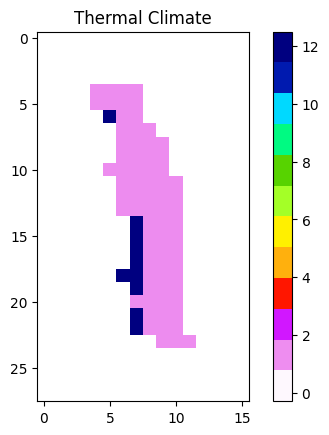

In [5]:
tclimate = clim_reg.getThermalClimate()

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tclimate, cmap=plt.get_cmap('gist_ncar_r', 12),vmin=-0.3,vmax=12.5)
plt.title('Thermal Climate')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_ThermalClimate_{year}.png",bbox_inches ="tight",dpi=300) #Save as PNG image
plt.show()

saveRaster(mask_path, f'./data_output/NB1/{country_name}_ThermalClimate_{year}.tif',tclimate) #Save as GeoTIFF raster

#### Thermal Zone
The thermal zone is classified based on actual temperature which reflects on the temperature regimes of major thermal climates

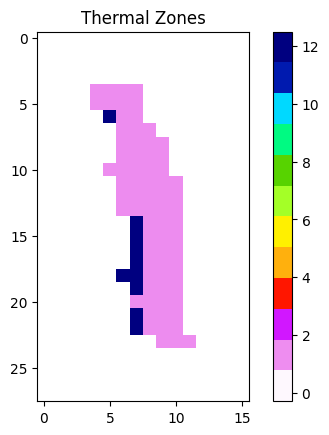

In [6]:
tzone = clim_reg.getThermalZone()

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tzone, cmap=plt.get_cmap('gist_ncar_r', 12),vmin=-0.3,vmax=12.5)
plt.title('Thermal Zones')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_ThermalZone_{year}.png",bbox_inches ="tight",dpi=300) #Save as PNG image
plt.show()

saveRaster(mask_path, f'./data_output/NB1/{country_name}_ThermalZone_{year}.tif',tzone) #Save as GeoTIFF raster

#### Thermal Length of Growing Period (LGP)
The thermal length of growing period (LGPt) is defined as the number of days in a year during which the daily mean temperature (Ta) is conductive to crop growth and development. PyAEZ utilizes the AEZ three standard temperature thresholds for LGPt:
- Periods with Ta>0°C (LGPt0)
- Periods with Ta>5°C (LGPt5) – the period conductive to plant growth and development
- Periods, and Ta>10°C (LGPt10) – a proxy for the period of low risks for late and early frost occurrences and termed ‘frost-free period’

In [7]:
lgpt0 = clim_reg.getThermalLGP0()
lgpt5 = clim_reg.getThermalLGP5()
lgpt10 = clim_reg.getThermalLGP10()

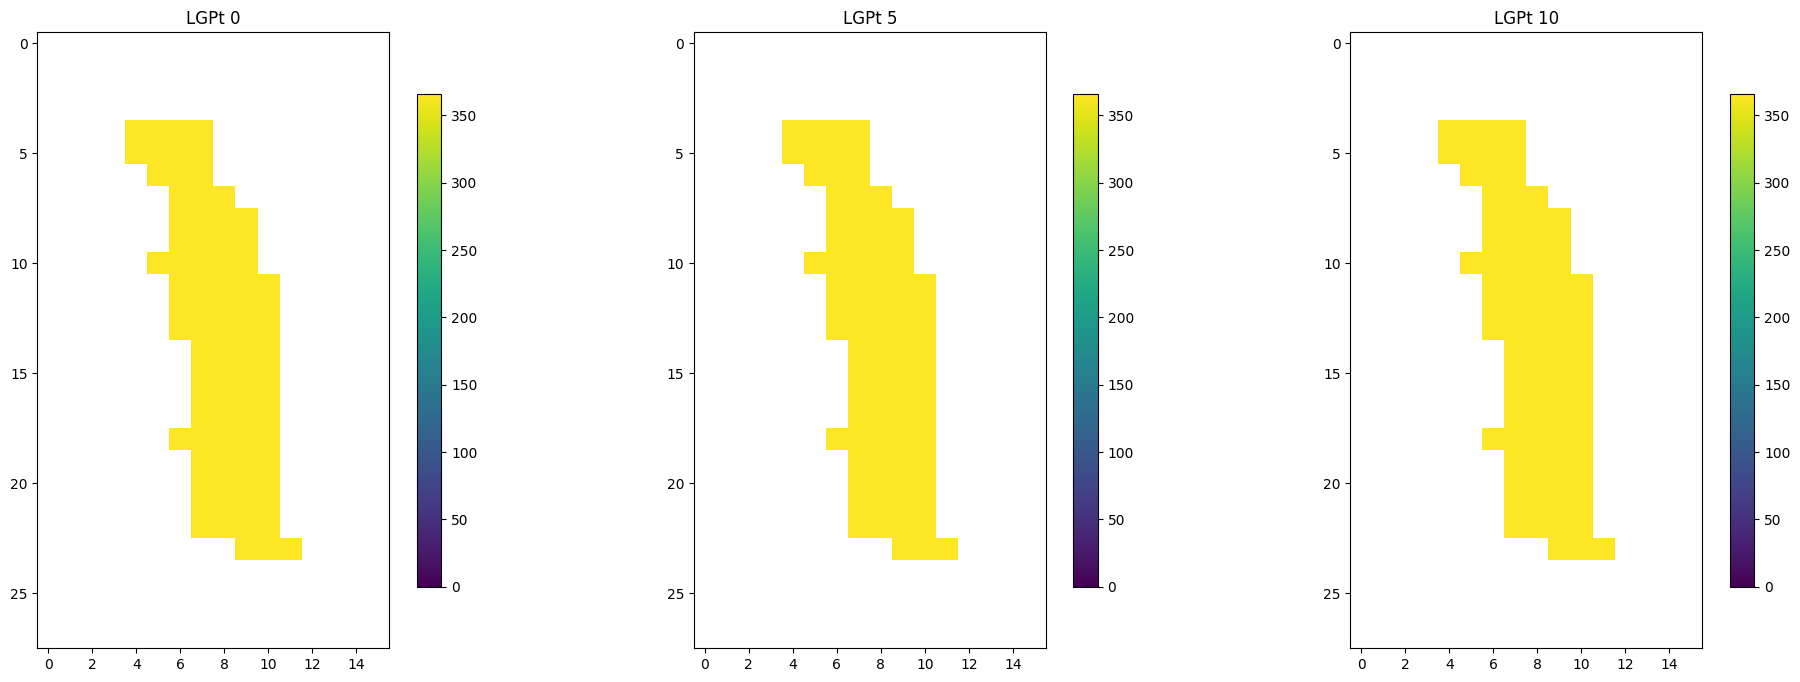

In [8]:
'''save and visualize result'''
#======================
plt.figure(1, figsize=(24, 8))
plt.subplot(1, 3, 1)
plt.imshow(lgpt0,vmin=0,vmax=366)
plt.title('LGPt 0')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 2)
plt.imshow(lgpt5, vmin=0, vmax=366)
plt.title('LGPt 5')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 3)
plt.imshow(lgpt10, vmin=0, vmax=366)
plt.title('LGPt 10')
plt.colorbar(shrink=0.8)
#----------------------
plt.savefig(f"./data_output/NB1/{country_name}_ThermalLGPs_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
#======================

saveRaster(mask_path, f'./data_output/NB1/{country_name}_LGPt0_{year}.tif', lgpt0)
saveRaster(mask_path, f'./data_output/NB1/{country_name}_LGPt5_{year}.tif', lgpt5)
saveRaster(mask_path, f'./data_output/NB1/{country_name}_LGPt10_{year}.tif', lgpt10)


#### Temperature Sum

In [9]:
tsum0 = clim_reg.getTemperatureSum0()
tsum5 = clim_reg.getTemperatureSum5()
tsum10 = clim_reg.getTemperatureSum10()

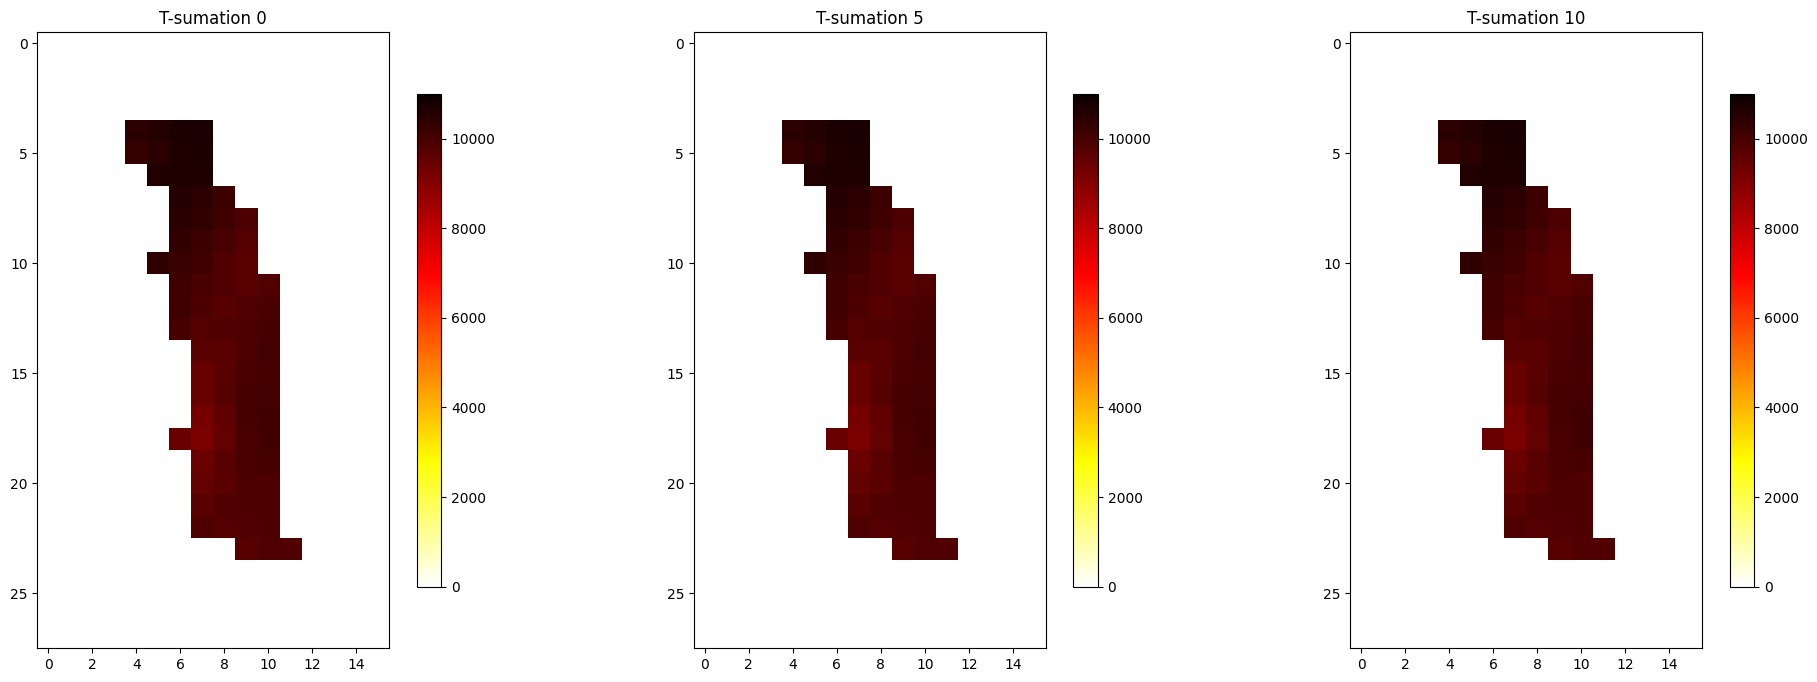

In [10]:
'''save and visualize result'''
#======================
plt.figure(1, figsize=(24, 8))
plt.subplot(1, 3, 1)
plt.imshow(tsum0, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 0')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 2)
plt.imshow(tsum5, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 5')
plt.colorbar(shrink=0.8)
#----------------------
plt.subplot(1, 3, 3)
plt.imshow(tsum10, cmap='hot_r', vmin=0, vmax=11000)
plt.title('T-sumation 10')
plt.colorbar(shrink=0.8)
#----------------------
plt.savefig(rf"./data_output/NB1/{country_name}_Tsum_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
#======================

saveRaster(mask_path, f'./data_output/NB1/{country_name}_tsum0_{year}.tif', tsum0)
saveRaster(mask_path, f'./data_output/NB1/{country_name}_tsum5_{year}.tif', tsum5)
saveRaster(mask_path, f'./data_output/NB1/{country_name}_tsum10_{year}.tif', tsum10)


#### Temperature Profile

In [11]:
tprofile = clim_reg.getTemperatureProfile()

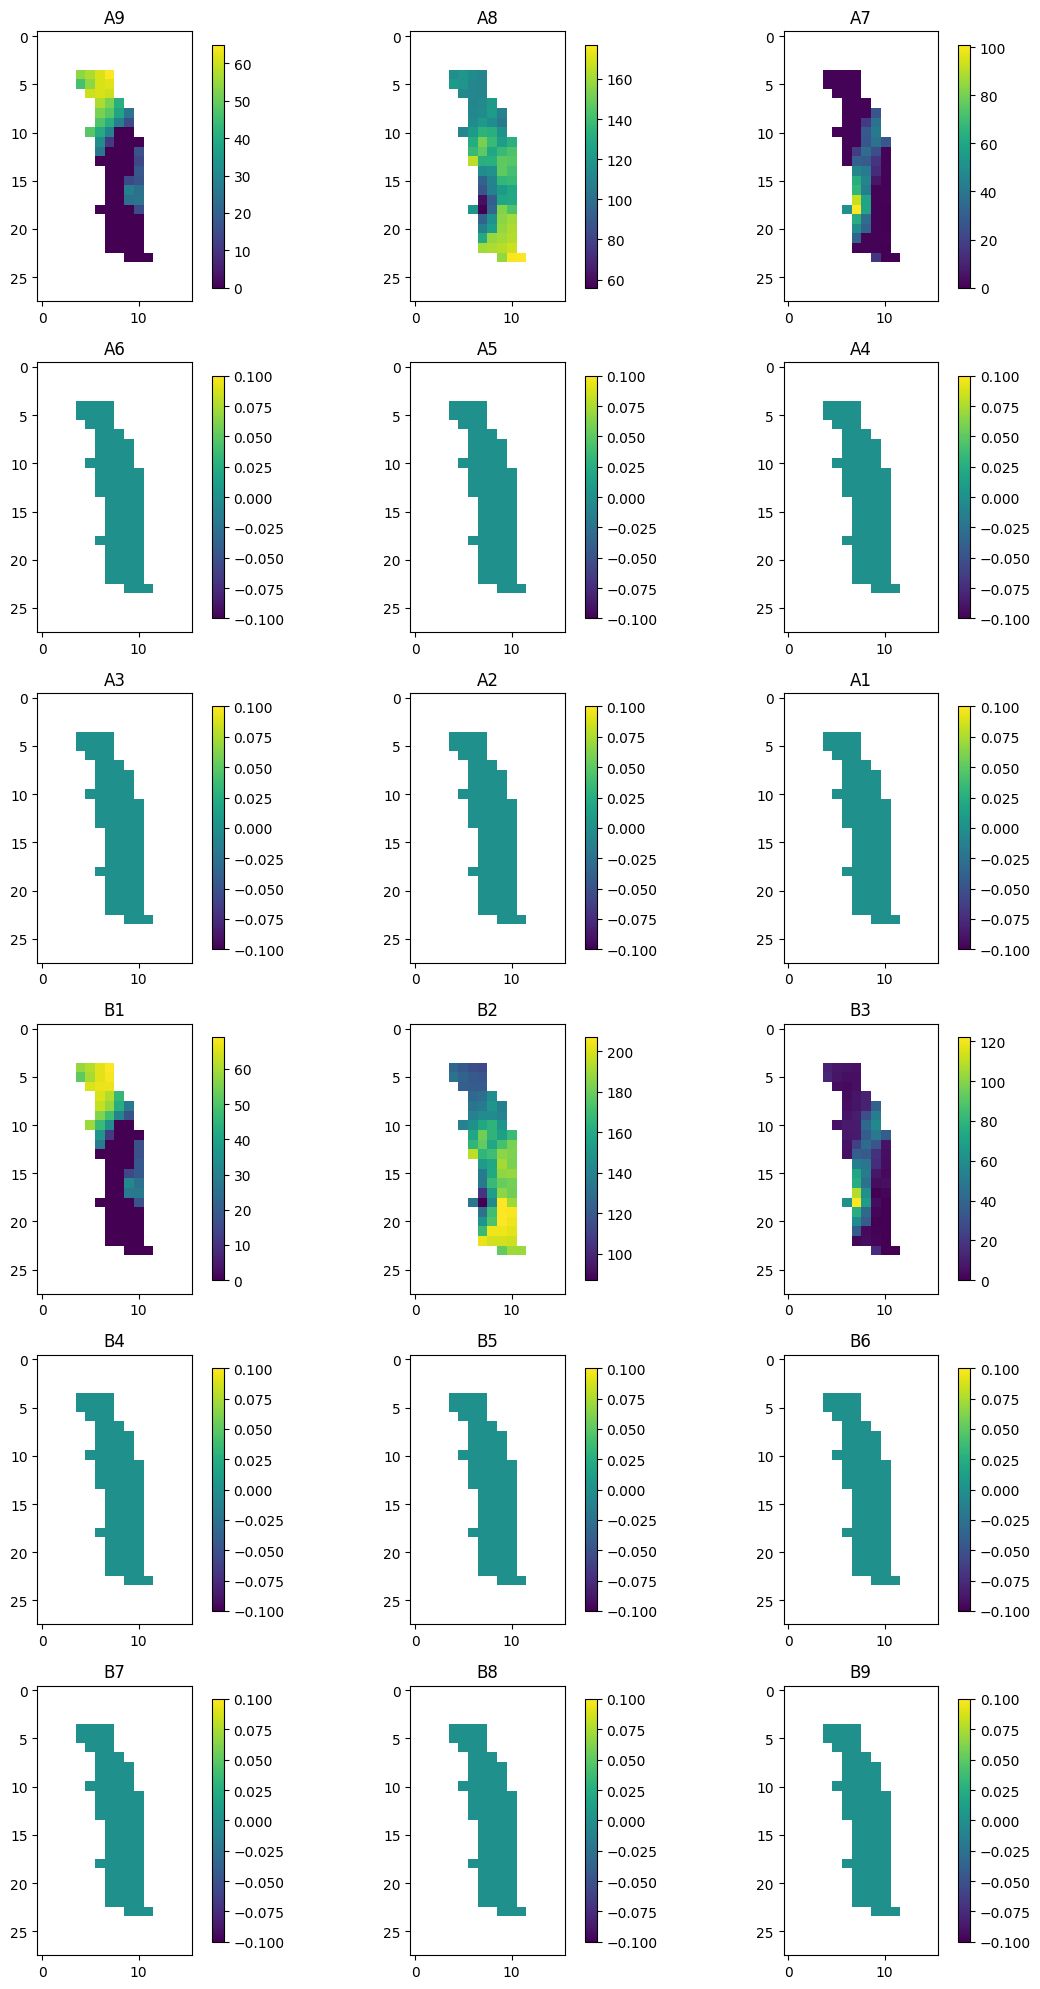

In [12]:
'''save and visualize result'''

tile_list = ['A9', 'A8', 'A7', 'A6', 'A5', 'A4', 'A3', 'A2',
             'A1', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9']

fig = plt.figure(figsize=(12, 20))
for i1 in range(1, 19):
    plt.subplot(6, 3, i1)
    plt.imshow(tprofile[i1-1])
    plt.title(tile_list[i1-1])
    plt.colorbar(shrink=0.9)
plt.tight_layout()

plt.savefig(rf"./data_output/NB1/{country_name}_Tprofiles_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()

for i1 in range(18):
    saveRaster(
        mask_path, f'./data_output/NB1/{country_name}_TProfile_' + tile_list[i1] + '.tif', tprofile[i1])
    #obj_utilities.saveRaster('./sample_data/input/LAO_Admin.tif', './sample_data/output/NB1/TProfile_' + tile_list[i1] +'.tif', tprofile[i1])


#### Length of Growing Periods (LGPs)

In [13]:
lgp = clim_reg.getLGP()
lgp_class = clim_reg.getLGPClassified(lgp)
lgp_equv = clim_reg.getLGPEquivalent()

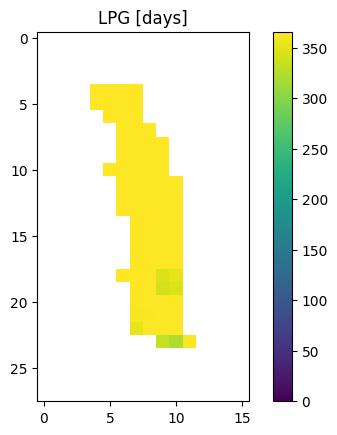

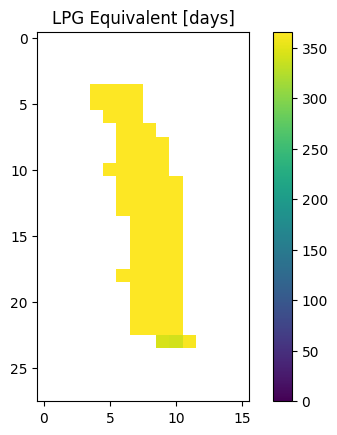

In [14]:
'''save and visualize result'''

plt.imshow(lgp, cmap='viridis', vmin=0, vmax=366)
plt.title('LPG [days]')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_LGP_{year}.png", bbox_inches="tight", dpi=300)
plt.show()


plt.imshow(lgp_equv, cmap='viridis', vmin=0, vmax=366)
plt.title('LPG Equivalent [days]')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_LGP_Equv_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()

saveRaster(mask_path, rf'./data_output/NB1/{country_name}_LGP_{year}.tif', lgp)

saveRaster(mask_path, rf'./data_output/NB1/{country_name}_LGPEquivalent_{year}.tif', lgp_equv)


#### Multi Cropping Zone
Multiple cropping zones classification is an additional agro-climatic indicator, which relates to the possibility of cultivating multiple sequential crops under rain-fed and irrigated conditions.

In [15]:
multi_crop = clim_reg.getMultiCroppingZones(tclimate, lgp, lgpt5, lgpt10, tsum0, tsum10)
multi_crop_rainfed = multi_crop[0]  # for rainfed conditions
multi_crop_irr = multi_crop[1]  # for irrigated conditions


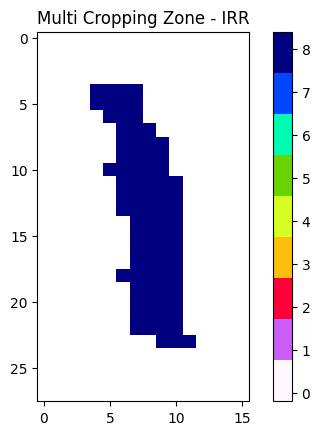

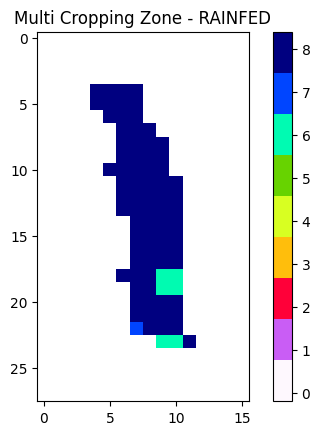

In [16]:
'''save and visualize result'''

plt.imshow(multi_crop_irr, cmap=plt.get_cmap('gist_ncar_r', 9), vmin=-0.2, vmax=8.4)
plt.title('Multi Cropping Zone - IRR')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_multicrop_irr_{year}.png", bbox_inches="tight", dpi=300)
plt.show()
saveRaster(
    mask_path, rf'./data_output/NB1/{country_name}_multicrop_irr_{year}.tif', multi_crop_irr)


plt.imshow(multi_crop_rainfed,cmap=plt.get_cmap('gist_ncar_r', 9), vmin=-0.2, vmax=8.4)
plt.title('Multi Cropping Zone - RAINFED')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_multicrop_rain_{year}.png",bbox_inches="tight", dpi=300)
plt.show()
saveRaster(
    mask_path, rf'./data_output/NB1/{country_name}_multicrop_rain_{year}.tif', multi_crop_rainfed)


### Air Frost Index and Permafrost Evaluation
Occurrence of continuous or discontinuous permafrost conditions are used in the suitability assessment. Permafrost areas are characterized by sub-soil at or below the freezing point for two or more years. In this section, PyAEZ utilizes the air frost index (FI) which is used to characterize climate-derived permafrost condition into 4 classes: 
1) Continuous permafrost
2) Discontinuous permafrost 
3) Sporadic permafrost
4) No permafrost

In [17]:
permafrost_eval = clim_reg.AirFrostIndexandPermafrostEvaluation()
frost_index = permafrost_eval[0]
permafrost = permafrost_eval[1]

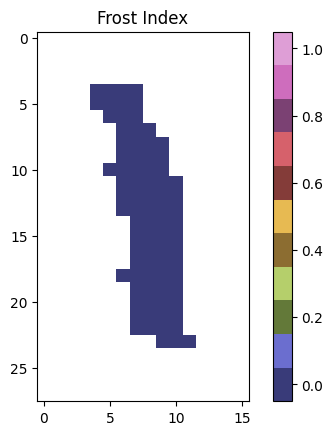

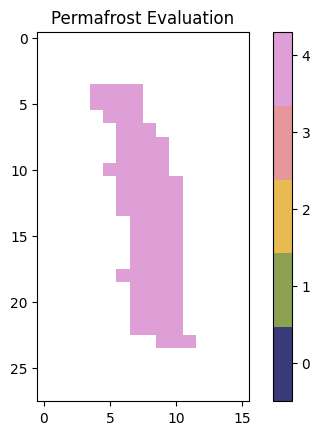

In [18]:
'''save and visualize result'''

plt.imshow(frost_index, cmap=plt.get_cmap(
    'tab20b', 11), vmin=-0.05, vmax=1.05)
plt.title('Frost Index')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_frost_index_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(
    mask_path, rf'./data_output/NB1/{country_name}_frost_index_{year}.tif', frost_index)



plt.imshow(permafrost, cmap=plt.get_cmap(
    'tab20b', 5), vmin=-0.5, vmax=4.3)
plt.title('Permafrost Evaluation')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_permafrost_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(
    mask_path, rf'./data_output/NB1/{country_name}_permafrost_{year}.tif', permafrost)


### Fallow period requirement
Fallow is an agricultural technique that consists of not sowing the arable land during one or more growing seasons. In AEZ framework, the fallow factors have been established by main crop groups and environmental conditions. The crop groups include cereals, legumes, roots and tubers, and a miscellaneous group consisting of long-term annuals/perennials. The fallow factors are expressed as percentage of time during the fallow-cropping cycle the land must be under fallow. PyAEZ determines the fallow requirements using Thermal Zones.

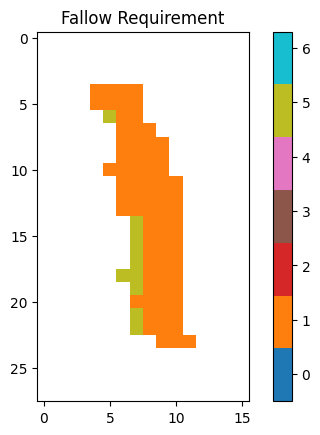

In [19]:
tzone_fallow = clim_reg.TZoneFallowRequirement(tzone)

'''save and visualize result'''
fig = plt.figure()
plt.imshow(tzone_fallow, cmap=plt.get_cmap('tab10', 7), vmin=-0.5, vmax=6.3)
plt.title('Fallow Requirement')
plt.colorbar()
plt.savefig(rf"./data_output/NB1/{country_name}_fallow_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(
    mask_path, rf'./data_output/NB1/{country_name}_fallow_{year}.tif', tzone_fallow)


### Agro-ecological zones classification
The agro-ecological zones (AEZ) methodology provides a framework for establishing a spatial inventory of land resources compiled from global/national environmental data sets and assembled to quantify multiple spatial characteristics required for the assessments of land productivity under location-specific agro-ecological conditions.

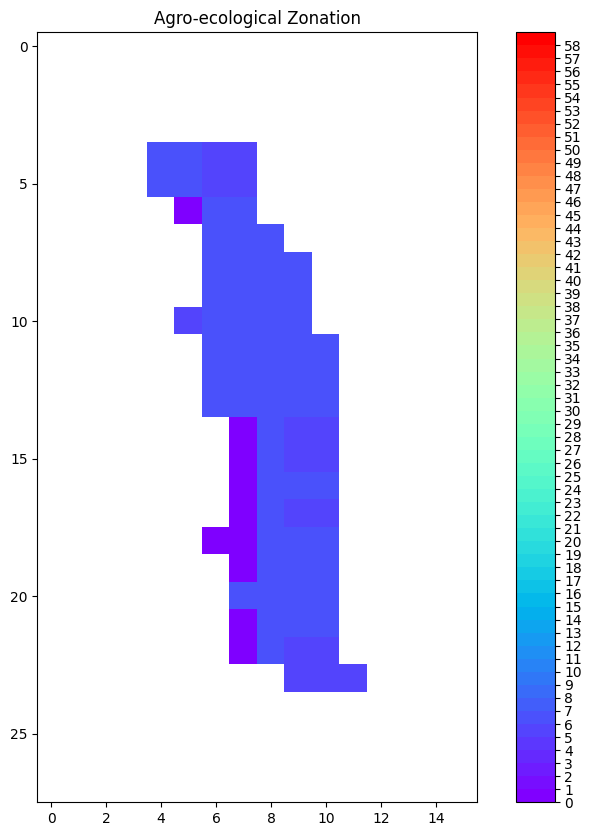

In [20]:
soil_terrain_lulc = gdal.Open(r'./data_input/togo_lulc_resampled_clipped.tif').ReadAsArray()

aez = clim_reg.AEZClassification(
    tclimate, lgp, lgp_equv, lgpt5, soil_terrain_lulc, permafrost)

# now visualizing result
fig = plt.figure(figsize= (10,10))
plt.imshow(aez, cmap=plt.get_cmap('rainbow', 59), vmin=0, vmax=59)
plt.title('Agro-ecological Zonation')
plt.colorbar(ticks = np.arange(0,59,1))
plt.savefig(rf"./data_output/NB1/{country_name}_aez_{year}.png", bbox_inches="tight", dpi=300)
plt.show()

saveRaster(
    mask_path, f'./data_output/NB1/{country_name}_aez_{year}.tif', aez)


### New indicator: Annual Temperature Amplitude 
The annual temperture amplitude provides information of how continental a region is. Calculated by the difference between the hottest month and the coldest month of the year.

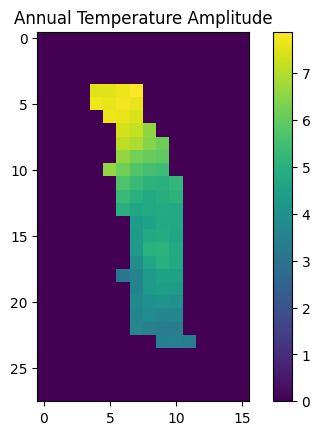

In [21]:
td2 = clim_reg.getAnnualTemperatureAmplitude()

# now visualizing result
fig = plt.figure()
plt.imshow(td2, cmap='viridis', vmin=np.nanmin(td2), vmax=np.nanmax(td2))
plt.title('Annual Temperature Amplitude')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_td2_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_td2_{year}.tif', td2)

### New Indicator: Reference Annual Total Potential Evapotranspiration (ET0) 
The total summation of potential evapotranspiration for a year.

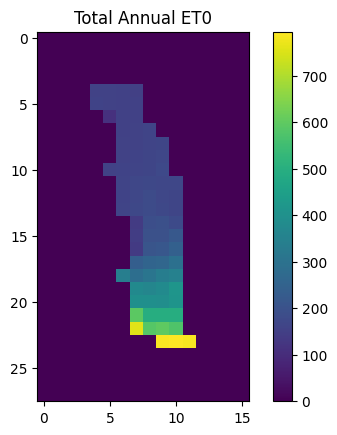

In [22]:
et0 = clim_reg.getETODaily()

# now visualizing result
fig = plt.figure()
plt.imshow(et0, cmap='viridis', vmin=np.nanmin(et0), vmax=np.nanmax(et0))
plt.title('Total Annual ET0')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_et0_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_et0_{year}.tif', et0)

### New Indicator: Annual Moisture Availability Index (P/ET0)
P/ET0 compares the incoming precipitation to the evaporative demand of a reference crop.
Values below 100 = water deficit
Values above 100 = precipitation exceeds evaporative demand

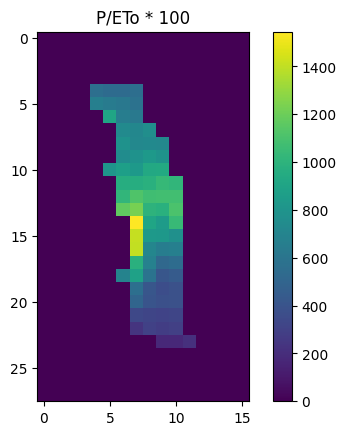

In [23]:
p_et0 = clim_reg.getAnnualMoistureAvailabilityIndex()

# now visualizing result
fig = plt.figure()
plt.imshow(p_et0, cmap='viridis', vmin=np.nanmin(p_et0), vmax=np.nanmax(p_et0))
plt.title('P/ETo * 100')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_p_eto_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_p_et0_{year}.tif', p_et0)

### New Indicator: Annual total reference actual evapotranspiration (ETa)
The total summation of actual evapotranspiration of the reference crop for a year.

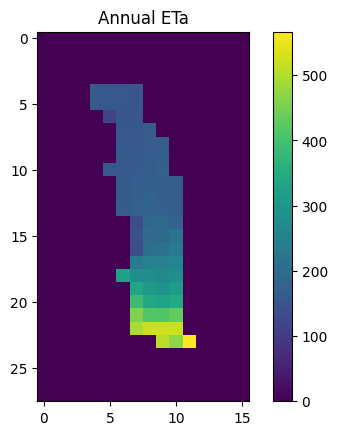

In [24]:
eta = clim_reg.getETaDaily()

# now visualizing result
fig = plt.figure()
plt.imshow(eta, cmap='viridis', vmin=np.nanmin(eta), vmax=np.nanmax(eta))
plt.title('Annual ETa')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_eta_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_eta_{year}.tif', eta)

### New Indicator: Annual total reference water deficit (Wde)
The difference the annual potential and actual evapotranspiration (Wde = ETm - ETa) to measure the discrepency the evaporative demand of a well-watered vegetation and the actual moisture supply under rainfed condition.
This indicator comes from reference water balance but does not consider actual soil condition.

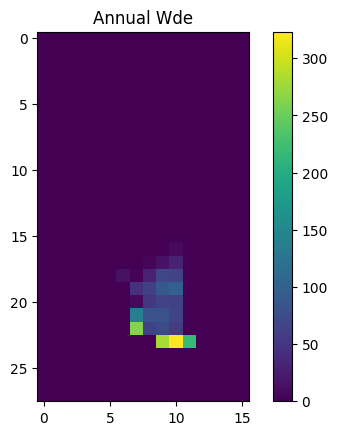

In [25]:
wde = clim_reg.getReferenceAnnualWaterDeficit()

# now visualizing result
fig = plt.figure()
plt.imshow(wde, cmap='viridis', vmin=np.nanmin(wde), vmax=np.nanmax(wde))
plt.title('Annual Wde')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_wde_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_wde_{year}.tif', wde)

### New Indicator: Net Primary Productivity (NPP)
NPP estimates a polynomial function of incoming solar radiation and soil moisture at the rhizosphere.
Calculated based on daily ETa to serve as a climate related indicator of rainfed biological activity.
Different routines are established for irrigated and rainfed conditions.

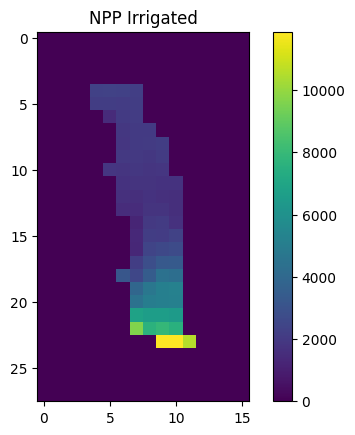

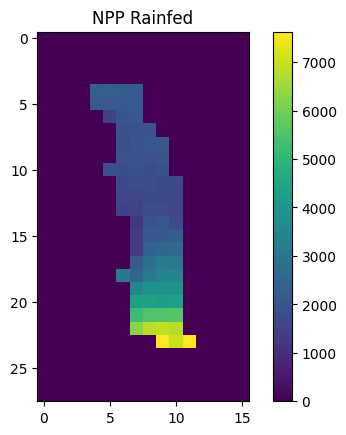

In [26]:
nppi = clim_reg.getNPP('I')
nppr = clim_reg.getNPP('R')

# now visualizing result
fig = plt.figure()
plt.imshow(nppi, cmap='viridis', vmin=np.nanmin(nppi), vmax=np.nanmax(nppi))
plt.title('NPP Irrigated')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_nppi_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_nppi_{year}.tif', nppi)

# now visualizing result
fig = plt.figure()
plt.imshow(nppr, cmap='viridis', vmin=np.nanmin(nppr), vmax=np.nanmax(nppr))
plt.title('NPP Rainfed')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_nppr_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_nppr_{year}.tif', nppr)

### New indicator: LGP of the Longest Componenets
In reality, LGP cycles can be more than one. This agro-climatic indicators detects all possible LGP cycles and produces the number of growing days with the longest LGP cycle as output.

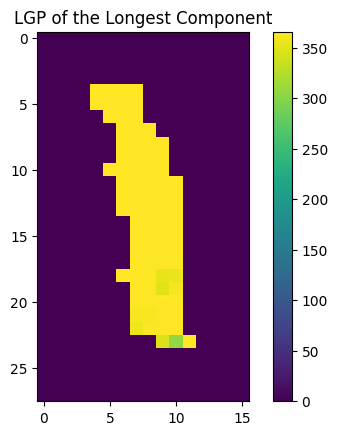

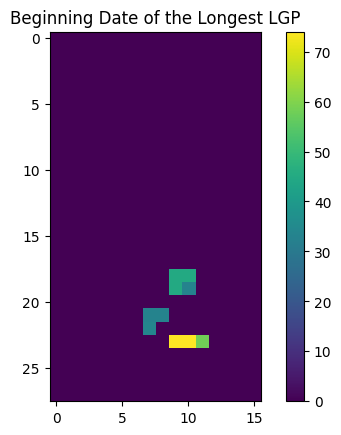

In [29]:
lgp_longest, lgp_beginday = clim_reg.getLGPlongest()

# now visualizing result
fig = plt.figure()
plt.imshow(lgp_longest, cmap='viridis', vmin=np.nanmin(lgp_longest), vmax=np.nanmax(lgp_longest))
plt.title('LGP of the Longest Component')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgplongest_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgplongest_{year}.tif', lgp_longest)

# now visualizing result
fig = plt.figure()
plt.imshow(lgp_beginday, cmap='viridis', vmin=np.nanmin(lgp_beginday), vmax=np.nanmax(lgp_beginday))
plt.title('Beginning Date of the Longest LGP')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgb_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgb_{year}.tif', lgp_beginday)


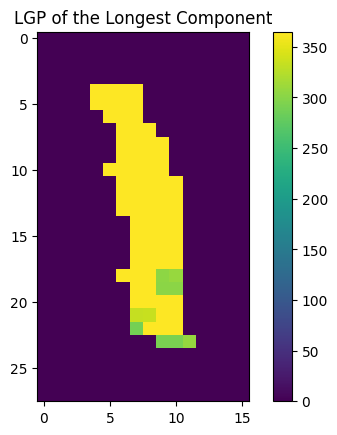

In [30]:
lgp_longest = clim_reg.getLGPlongest_ver2()

# now visualizing result
fig = plt.figure()
plt.imshow(lgp_longest, cmap='viridis', vmin=np.nanmin(lgp_longest), vmax=np.nanmax(lgp_longest))
plt.title('LGP of the Longest Component')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgplongest_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgplongest_{year}.tif', lgp_longest)


### New indicator: Beginning Date of the LGP Longest
This indicator produces the starting date of the longest componenet of LGP cycle.

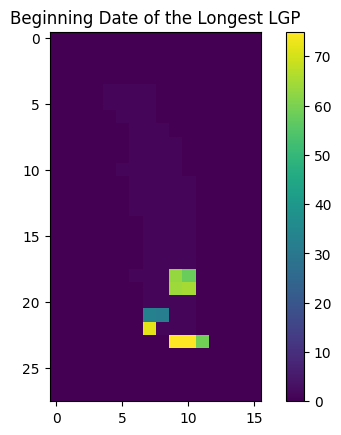

In [31]:
lgb = clim_reg.getLGPlongestBeginDate()

# now visualizing result
fig = plt.figure()
plt.imshow(lgb, cmap='viridis', vmin=np.nanmin(lgb), vmax=np.nanmax(lgb))
plt.title('Beginning Date of the Longest LGP')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgb_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgb_{year}.tif', lgb)


### New indicator: Beginning Date of the hibernation period
This indicator produces the starting date of the hibernation period

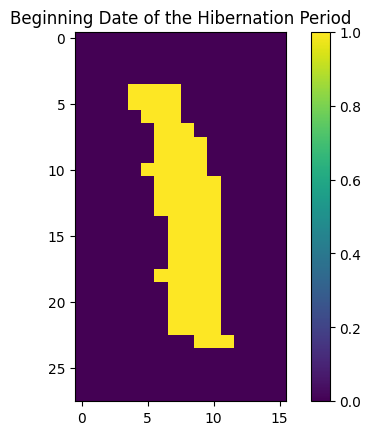

In [29]:
lgh_b = clim_reg.getBeginningDateofHibernationPeriod()

# now visualizing result
fig = plt.figure()
plt.imshow(lgh_b, cmap='viridis', vmin=np.min(lgh_b), vmax=np.nanmax(lgh_b))
plt.title('Beginning Date of the Hibernation Period')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgh_b_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgh_b_{year}.tif', lgb)

### New indicator: Length of the Dormancy period
This indicator produces the starting date of the hibernation period, one of the useful component for the crops which needs dormnacy period.

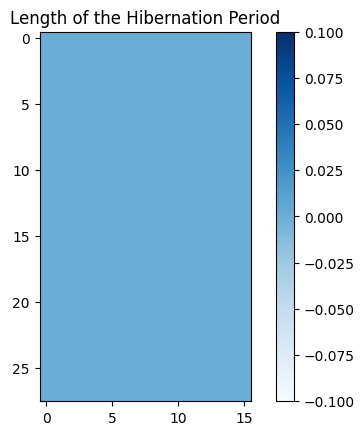

In [30]:
lgh = clim_reg.getHibernationPeriodLength()

# now visualizing result
fig = plt.figure()
plt.imshow(lgh, cmap='Blues', vmin=np.min(lgh), vmax=np.nanmax(lgh))
plt.title('Length of the Hibernation Period')
plt.colorbar()
plt.savefig(f"./data_output/NB1/{country_name}_lgh_{year}.png",
            bbox_inches="tight", dpi=300)
plt.show()
saveRaster(mask_path, f'./data_output/NB1/{country_name}_lgh_{year}.tif', lgb)

<hr>

### END OF MODULE 1: CLIMATE REGIME

<hr>